<h2>Perform an in-depth univariate and multivariate statistical analysis to explore data distributions, detect hidden patterns, and understand relationships between numerical and categorical variables across the entire dataset.</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
medicines = pd.read_csv(r'C:\Users\rutva\Downloads\DS AIML Projects\Daily tasks\Pharmacy management system\archive\medicines.csv')
sales_item = pd.read_csv(r'C:\Users\rutva\Downloads\DS AIML Projects\Daily tasks\Pharmacy management system\archive\sales_item.csv')

In [5]:
medicines

,,id,name,generic_name,category,description,strength,dosage_form,purchase_price,selling_price,mrp,current_stock,reorder_level,batch_number,expiry_date,supplier,manufacturer,is_prescription_required,is_seasonal,season_category
1,Amoxicillin 500mg,Amoxicillin,Antibiotics,Broad-spectrum antibiotic for bacterial infect...,urinary tract,and skin infections.,500mg,Capsule,12.0,25.0,30.0,120,20,AMX-2027-001,2027-08-15,Cipla Limited,Cipla Limited,TRUE,False,NaN
2,Azithromycin 500mg,Azithromycin,Antibiotics,Antibiotic for respiratory infections,skin infections,and ear infections.,500mg,Tablet,40.0,65.0,75.0,85,15,AZM-2027-002,2027-06-30,Sun Pharma,Sun Pharma,TRUE,True,Monsoon
3,Ciprofloxacin 500mg,Ciprofloxacin,Antibiotics,Broad-spectrum antibiotic for urinary tract in...,respiratory infections.,500mg,Tablet,25.00,45.0,55.0,60.0,10,CIP-2027-003,2027-09-20,Dr. Reddy's,Dr. Reddy's,TRUE,FALSE,NaN,NaN
4,Doxycycline 100mg,Doxycycline,Antibiotics,Tetracycline antibiotic for bacterial infections,acne,and malaria prophylaxis.,100mg,Capsule,18.0,35.0,42.0,95,15,DOX-2027-004,2027-11-10,Glenmark,Glenmark,TRUE,True,Summer
5,Metronidazole 400mg,Metronidazole,Antibiotics,Antibiotic for anaerobic bacterial infections ...,400mg,Tablet,8.00,15.00,20.0,150.0,25.0,MET-2027-006,2027-10-05,Sun Pharma,Sun Pharma,TRUE,FALSE,NaN,NaN,NaN
6,Metformin 500mg,Metformin,Antidiabetics,First-line medication for type 2 diabetes. Red...,500mg,Tablet,5.00,10.00,15.0,200.0,30.0,MET-500-2027,2028-03-15,Cipla,Cipla,TRUE,FALSE,NaN,NaN,NaN
7,Glimepiride 2mg,Glimepiride,Antidiabetics,Sulfonylurea medication for type 2 diabetes.,2mg,Tablet,8.00,16.00,22.0,120.0,20.0,GLIM-2027-002,2027-12-20,Sun Pharma,Sun Pharma,TRUE,FALSE,NaN,NaN,NaN
8,Empagliflozin 25mg,Empagliflozin,Antidiabetics,SGLT2 inhibitor for type 2 diabetes.,25mg,Tablet,50.00,85.00,100.0,55.0,10.0,EMPA-2027-005,2028-02-28,Cipla,Cipla,TRUE,FALSE,NaN,NaN,NaN
9,Amlodipine 5mg,Amlodipine,Antihypertensives,Calcium channel blocker for hypertension and a...,5mg,Tablet,4.00,8.00,12.0,180.0,25.0,AMLO-2027-001,2028-04-20,Dr. Reddy's,Dr. Reddy's,TRUE,FALSE,NaN,NaN,NaN
10,Losartan 50mg,Losartan,Antihypertensives,ARB for hypertension and diabetic nephropathy.,50mg,Tablet,6.00,12.00,18.0,150.0,20.0,LOS-2027-002,2028-06-10,Sun Pharma,Sun Pharma,TRUE,FALSE,NaN,NaN,NaN


In [6]:
medicines['purchase_price_num'] = pd.to_numeric(medicines['purchase_price'], errors='coerce')
medicines['selling_price_num'] = pd.to_numeric(medicines['selling_price'], errors='coerce')
medicines['mrp_num'] = pd.to_numeric(medicines['mrp'], errors='coerce')

In [7]:
sales_item['quantity_num'] = pd.to_numeric(sales_item['quantity'], errors='coerce')
sales_item['unit_price_num'] = pd.to_numeric(sales_item['unit_price'], errors='coerce')
sales_item['total_amount_num'] = pd.to_numeric(sales_item['total_amount'], errors='coerce')

C:\Users\rutva\AppData\Local\Temp\ipykernel_3952\1420301272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


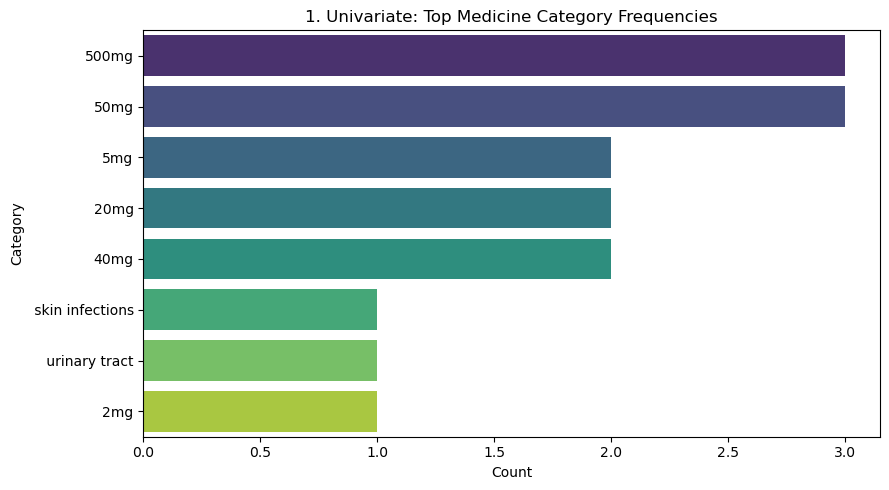

In [8]:
plt.figure(figsize=(9, 5))
category_counts = medicines['category'].value_counts().head(8)
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('1. Univariate: Top Medicine Category Frequencies')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

C:\Users\rutva\AppData\Local\Temp\ipykernel_3952\1651897619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


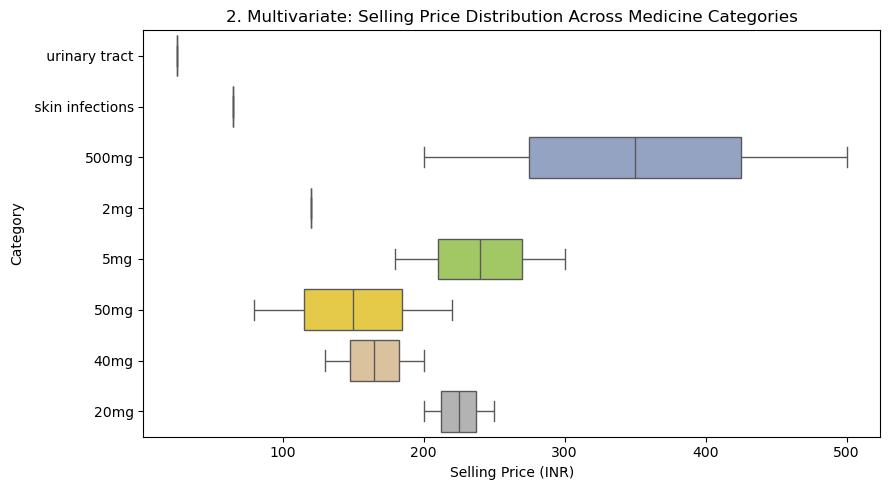

In [9]:
plt.figure(figsize=(9, 5))
top_cats = medicines['category'].value_counts().head(8).index
sns.boxplot(
    data=medicines[medicines['category'].isin(top_cats)], 
    x='selling_price_num', 
    y='category', 
    palette='Set2'
)
plt.title('2. Multivariate: Selling Price Distribution Across Medicine Categories')
plt.xlabel('Selling Price (INR)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

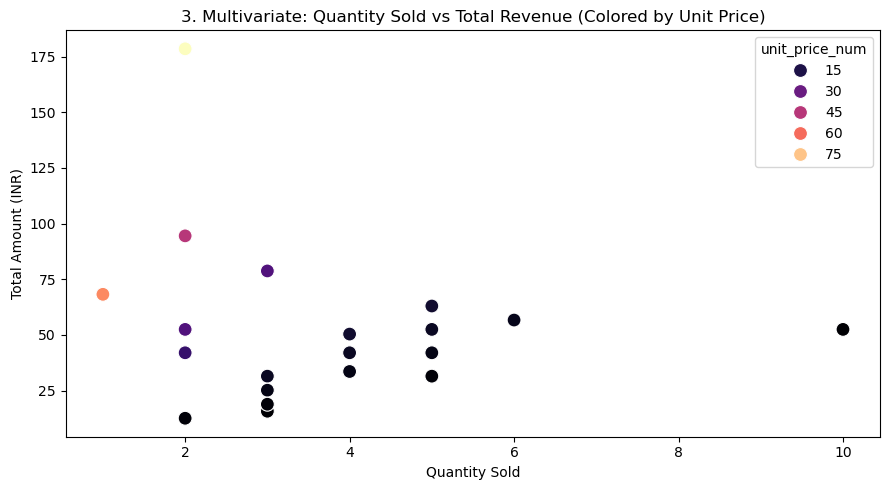

In [10]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=sales_item, 
    x='quantity_num', 
    y='total_amount_num', 
    hue='unit_price_num', 
    palette='magma', 
    s=100
)
plt.title('3. Multivariate: Quantity Sold vs Total Revenue (Colored by Unit Price)')
plt.xlabel('Quantity Sold')
plt.ylabel('Total Amount (INR)')
plt.tight_layout()
plt.show()